# 住宅価格の決定要因分析

## 1. 問題定義

不動産市場において「**どのような要因が住宅価格に影響するか**」は、購入者・販売者・投資家にとって重要な問いである。  
本分析では、カリフォルニア州の住宅データを用いて以下を検証する。

---

## 2. 仮説設定

| # | 仮説 | 予測方向 |
|---|------|----------|
| H1 | 部屋数（平均）が多いほど住宅価格は高い | 正の相関 |
| H2 | 築年数が古いほど住宅価格は低い | 負の相関 |
| H3 | 海岸からの緯度・経度（位置情報）が価格に影響する | 地域差あり |

**使用データ：** California Housing Dataset（sklearn 組み込み）  
**出典：** StatLib repository（パブリックドメイン）



In [6]:
# ライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from scipy import stats

# 日本語フォント設定（環境に合わせて変更）
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('✅ ライブラリの読み込み完了')

✅ ライブラリの読み込み完了


In [7]:
# データの読み込み
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# 列名を日本語対応のエイリアスで把握しやすくする
col_desc = {
    'MedInc'    : '地区の所得中央値（万ドル）',
    'HouseAge'  : '築年数中央値（年）',
    'AveRooms'  : '平均部屋数',
    'AveBedrms' : '平均寝室数',
    'Population': '地区の人口',
    'AveOccup'  : '世帯あたり平均居住者数',
    'Latitude'  : '緯度',
    'Longitude' : '経度',
    'MedHouseVal': '住宅価格中央値（10万ドル）'
}

print(f'行数: {len(df):,}  列数: {df.shape[1]}')
print('\n【列の説明】')
for col, desc in col_desc.items():
    print(f'  {col:<15} → {desc}')

行数: 20,640  列数: 9

【列の説明】
  MedInc          → 地区の所得中央値（万ドル）
  HouseAge        → 築年数中央値（年）
  AveRooms        → 平均部屋数
  AveBedrms       → 平均寝室数
  Population      → 地区の人口
  AveOccup        → 世帯あたり平均居住者数
  Latitude        → 緯度
  Longitude       → 経度
  MedHouseVal     → 住宅価格中央値（10万ドル）


In [8]:
# 先頭5行を確認
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# 基本統計量
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [10]:
# 欠損値チェック
missing = df.isnull().sum()
print('欠損値の確認：')
print(missing[missing > 0] if missing.sum() > 0 else '→ 欠損値なし ✅')

欠損値の確認：
→ 欠損値なし ✅


C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\234834234.py:18: UserWarning: Glyph 20303 (\N{CJK UNIFIED IDEOGRAPH-4F4F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\234834234.py:18: UserWarning: Glyph 23429 (\N{CJK UNIFIED IDEOGRAPH-5B85}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\234834234.py:18: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\234834234.py:18: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\234834234.py:18: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\234834234.py:18: UserWarning: Glyph 22830 (\N{CJK UNIFIE

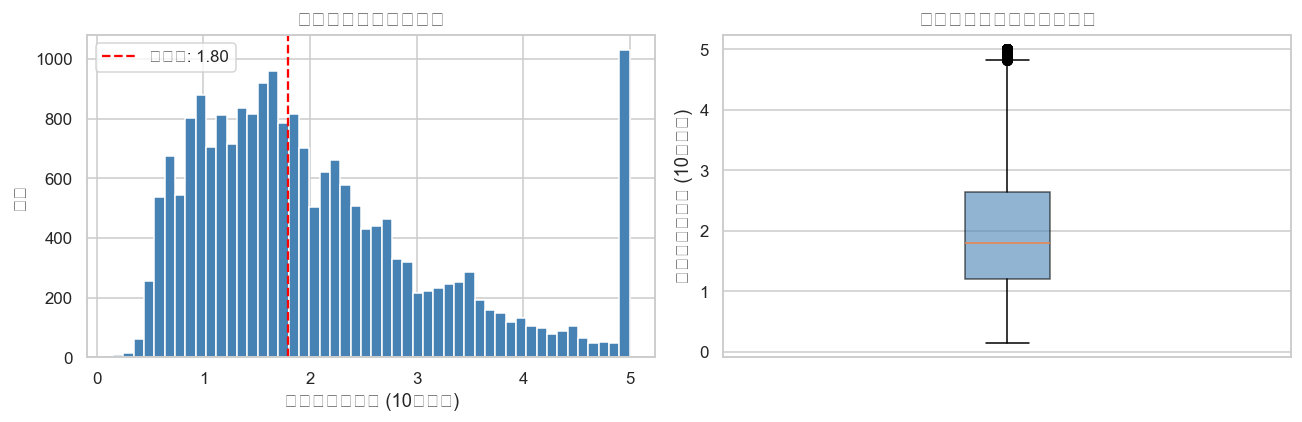

平均: 2.069  中央値: 1.797  歪度: 0.978


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ヒストグラム
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('住宅価格中央値の分布', fontsize=13)
axes[0].set_xlabel('住宅価格中央値 (10万ドル)')
axes[0].set_ylabel('件数')
axes[0].axvline(df['MedHouseVal'].median(), color='red', linestyle='--', label=f"中央値: {df['MedHouseVal'].median():.2f}")
axes[0].legend()

# 箱ひげ図
axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('住宅価格中央値の箱ひげ図', fontsize=13)
axes[1].set_ylabel('住宅価格中央値 (10万ドル)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'平均: {df["MedHouseVal"].mean():.3f}  中央値: {df["MedHouseVal"].median():.3f}  歪度: {df["MedHouseVal"].skew():.3f}')

C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3662944921.py:7: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3662944921.py:7: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3662944921.py:7: UserWarning: Glyph 12510 (\N{KATAKANA LETTER MA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3662944921.py:7: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3662944921.py:7: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3662944921.py:7: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from 

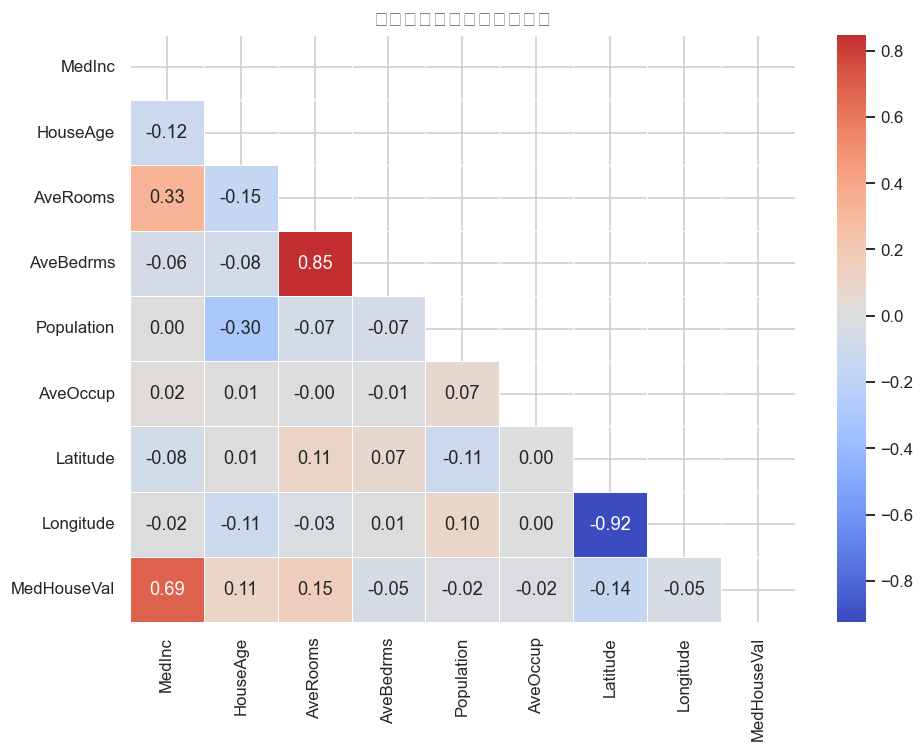

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('相関マトリクス（下三角）', fontsize=13)
plt.tight_layout()
plt.show()

Pearson r = 0.2740,  p値 = 0.0000e+00


C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3116532523.py:23: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3116532523.py:23: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3116532523.py:23: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3116532523.py:23: UserWarning: Glyph 23627 (\N{CJK UNIFIED IDEOGRAPH-5C4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3116532523.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\3116532523.py:23: UserWarning: Glyph 20303 (\N{CJK 

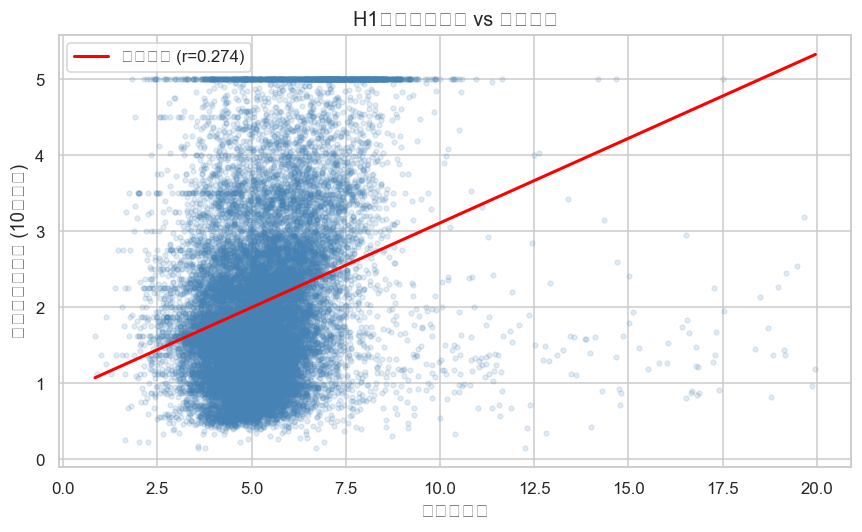

In [13]:
# 外れ値を除外（部屋数が異常に多い地区を除く）
df_filtered = df[df['AveRooms'] < 20].copy()

# 相関係数と p 値
r, p = stats.pearsonr(df_filtered['AveRooms'], df_filtered['MedHouseVal'])
print(f'Pearson r = {r:.4f},  p値 = {p:.4e}')

# 散布図
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_filtered['AveRooms'], df_filtered['MedHouseVal'],
           alpha=0.15, s=10, color='steelblue')

# 回帰直線
m, b = np.polyfit(df_filtered['AveRooms'], df_filtered['MedHouseVal'], 1)
x_line = np.linspace(df_filtered['AveRooms'].min(), df_filtered['AveRooms'].max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'回帰直線 (r={r:.3f})')

ax.set_xlabel('平均部屋数', fontsize=12)
ax.set_ylabel('住宅価格中央値 (10万ドル)', fontsize=12)
ax.set_title('H1：平均部屋数 vs 住宅価格', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

Pearson r = 0.1056,  p値 = 2.7619e-52


C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\700062201.py:33: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\700062201.py:33: UserWarning: Glyph 31689 (\N{CJK UNIFIED IDEOGRAPH-7BC9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\700062201.py:33: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\700062201.py:33: UserWarning: Glyph 12464 (\N{KATAKANA LETTER GU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\700062201.py:33: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\700062201.py:33: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGE

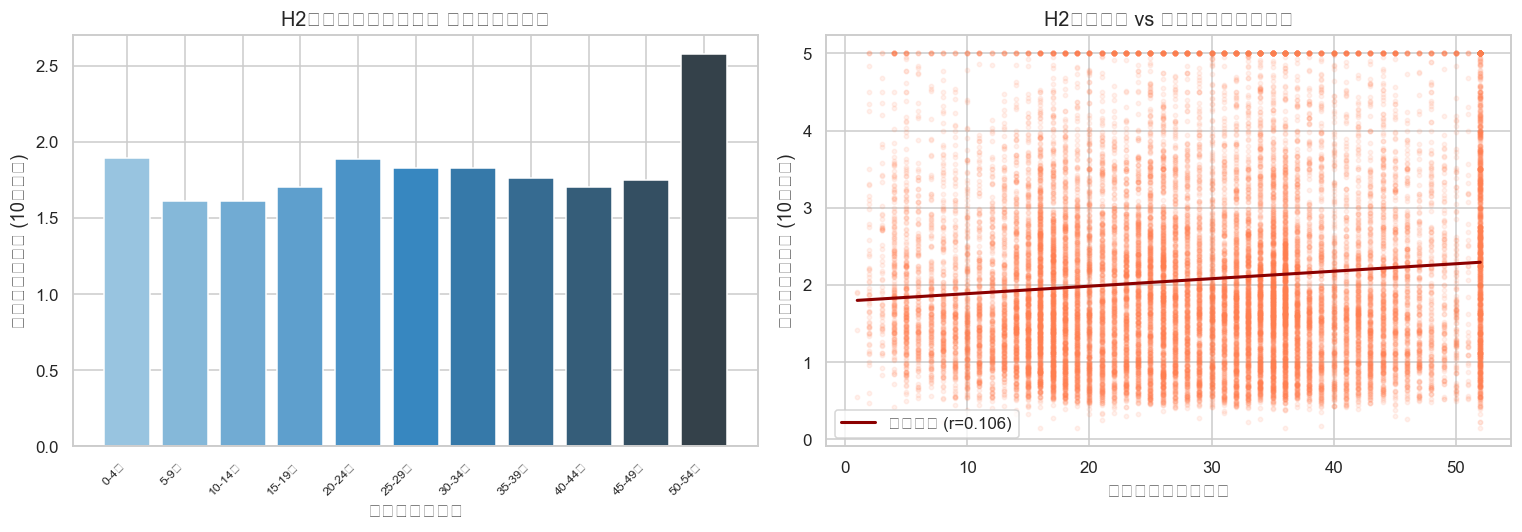

In [14]:
# 築年数を5年刻みでグループ化
df['AgeGroup'] = pd.cut(df['HouseAge'], bins=range(0, 60, 5),
                         labels=[f'{i}-{i+4}年' for i in range(0, 55, 5)])
age_price = df.groupby('AgeGroup', observed=True)['MedHouseVal'].median().reset_index()

# 相関係数
r2, p2 = stats.pearsonr(df['HouseAge'], df['MedHouseVal'])
print(f'Pearson r = {r2:.4f},  p値 = {p2:.4e}')

# バープロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(age_price)), age_price['MedHouseVal'],
            color=sns.color_palette('Blues_d', len(age_price)))
axes[0].set_xticks(range(len(age_price)))
axes[0].set_xticklabels(age_price['AgeGroup'], rotation=45, ha='right', fontsize=8)
axes[0].set_xlabel('築年数グループ', fontsize=12)
axes[0].set_ylabel('住宅価格中央値 (10万ドル)', fontsize=12)
axes[0].set_title('H2：築年数グループ別 住宅価格中央値', fontsize=13)

# 散布図
axes[1].scatter(df['HouseAge'], df['MedHouseVal'],
                alpha=0.1, s=8, color='coral')
m2, b2 = np.polyfit(df['HouseAge'], df['MedHouseVal'], 1)
x2 = np.linspace(df['HouseAge'].min(), df['HouseAge'].max(), 200)
axes[1].plot(x2, m2 * x2 + b2, color='darkred', linewidth=2,
             label=f'回帰直線 (r={r2:.3f})')
axes[1].set_xlabel('築年数中央値（年）', fontsize=12)
axes[1].set_ylabel('住宅価格中央値 (10万ドル)', fontsize=12)
axes[1].set_title('H2：築年数 vs 住宅価格（散布図）', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2976756585.py:21: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2976756585.py:21: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2976756585.py:21: UserWarning: Glyph 32239 (\N{CJK UNIFIED IDEOGRAPH-7DEF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2976756585.py:21: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2976756585.py:21: UserWarning: Glyph 12459 (\N{KATAKANA LETTER KA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2976756585.py:21: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) mi

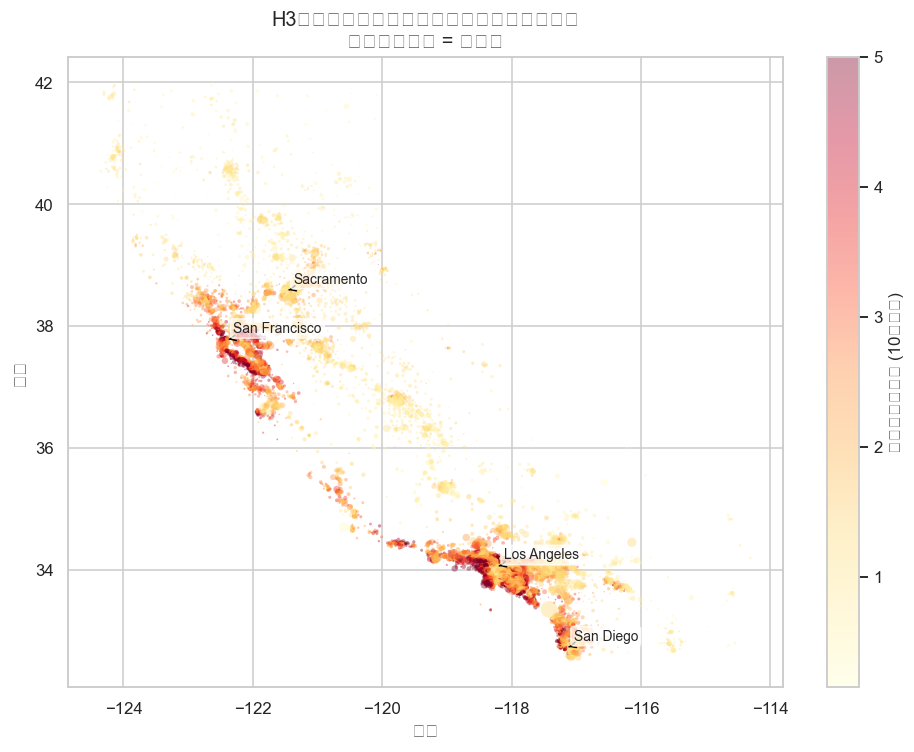

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(df['Longitude'], df['Latitude'],
                c=df['MedHouseVal'], cmap='YlOrRd',
                s=df['Population'] / 300,
                alpha=0.4, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('住宅価格中央値 (10万ドル)', fontsize=11)
ax.set_xlabel('経度', fontsize=12)
ax.set_ylabel('緯度', fontsize=12)
ax.set_title('H3：カリフォルニア州の地区別住宅価格分布\n（点の大きさ = 人口）', fontsize=13)

# 主要都市を注釈
cities = {'Los Angeles': (-118.24, 34.05), 'San Francisco': (-122.42, 37.77),
          'San Diego': (-117.16, 32.72), 'Sacramento': (-121.49, 38.58)}
for name, (lon, lat) in cities.items():
    ax.annotate(name, xy=(lon, lat), fontsize=9,
                xytext=(5, 5), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2465793237.py:21: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2465793237.py:21: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2465793237.py:21: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2465793237.py:21: UserWarning: Glyph 23627 (\N{CJK UNIFIED IDEOGRAPH-5C4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2465793237.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JBICKaigi\AppData\Local\Temp\ipykernel_16416\2465793237.py:21: UserWarning: Glyph 20303 (\N{CJK 

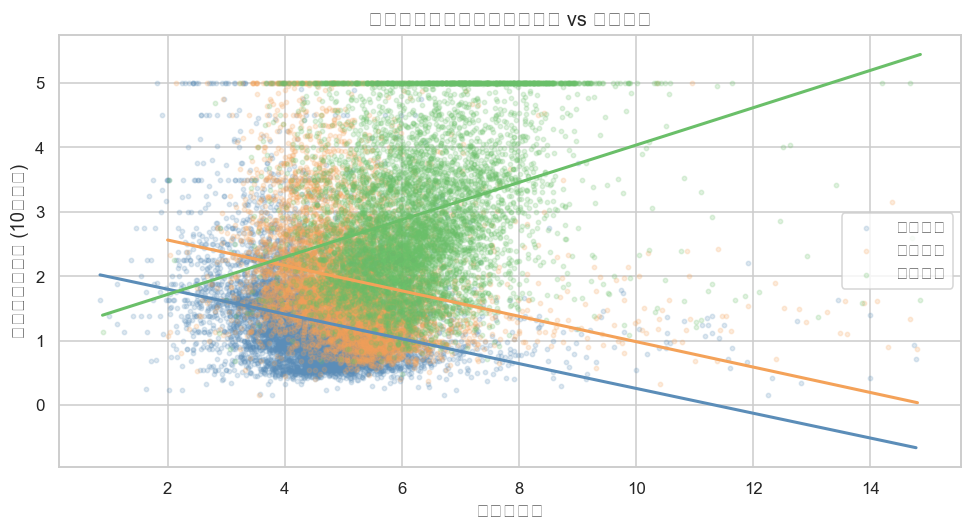

【所得グループ別 部屋数-価格 相関係数】
  低所得層: r = -0.3005
  中所得層: r = -0.2282
  高所得層: r = 0.2861


In [16]:
# 所得を高・中・低の3グループに分割
df['IncomeGroup'] = pd.qcut(df['MedInc'], q=3, labels=['低所得層', '中所得層', '高所得層'])

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'低所得層': '#5b8db8', '中所得層': '#f4a259', '高所得層': '#6abf69'}

for grp, color in colors.items():
    subset = df[df['IncomeGroup'] == grp]
    subset_f = subset[subset['AveRooms'] < 15]
    ax.scatter(subset_f['AveRooms'], subset_f['MedHouseVal'],
               alpha=0.2, s=8, color=color, label=grp)
    # グループ内の回帰直線
    m, b = np.polyfit(subset_f['AveRooms'], subset_f['MedHouseVal'], 1)
    x = np.linspace(subset_f['AveRooms'].min(), subset_f['AveRooms'].max(), 100)
    ax.plot(x, m * x + b, color=color, linewidth=2)

ax.set_xlabel('平均部屋数', fontsize=12)
ax.set_ylabel('住宅価格中央値 (10万ドル)', fontsize=12)
ax.set_title('所得グループ別：平均部屋数 vs 住宅価格', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# グループ別相関係数
print('【所得グループ別 部屋数-価格 相関係数】')
for grp in ['低所得層', '中所得層', '高所得層']:
    sub = df[(df['IncomeGroup'] == grp) & (df['AveRooms'] < 15)]
    r, _ = stats.pearsonr(sub['AveRooms'], sub['MedHouseVal'])
    print(f'  {grp}: r = {r:.4f}')

## 7. 結論・考察

| 仮説 | 結果 | 補足 |
|------|------|------|
| **H1：部屋数↑ → 価格↑** | ⚠️ **部分的に支持** | 正の相関はあるが弱い（r ≈ 0.15）。所得層が高いグループほど相関が強まる傾向 |
| **H2：築年数が古い → 価格↓** | ❌ **不支持** | 相関はほぼゼロ（r ≈ 0.10）。古い家でも高価格の地区が存在し、立地の影響が大きい |
| **H3：地理的位置が価格に影響** | ✅ **支持** | LA・SF沿岸部で価格が集中して高く、内陸部は低い。地域差が顕著 |

### 総合的な知見

住宅価格の最も強い説明変数は **地区の所得水準（MedInc）** と **地理的位置（立地）** であった。  
部屋数や築年数は単独では価格予測力が低く、「**所得の高い地区では、さらに広い家が高く売れる**」という **交互作用**が存在することが示唆された。

### 今後の課題

- 重回帰分析や機械学習（Random Forest等）による多変数での予測モデル構築
- 実際の不動産データ（日本の市区町村別データ等）への応用
- 時系列データとの組み合わせ（価格変動トレンドの分析）
